__Markus Mulvihill__

__Last updated April 2026__

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tomllib
import plt_config

In [2]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "04"
num_particles = cfg[curr_module]["num_particles"]
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]
dev_perc = cfg[curr_module]["dev_perc"]
deviations = cfg[curr_module]["deviations"]
num_patients = cfg[curr_module]["num_patients"]
num_deviations = len(deviations)

 

Within this file, different methods of parameter estimation will be implemented and compared to predict the Insulin Sensitivity $\, SI$ in patients

In [3]:
try:
    SI_ests = np.load(
        "../scripts/saved_variables/module4/SI_ests_integral_static_04.npy"
    )
    SI_errs = np.load(
        "../scripts/saved_variables/module4/SI_errs_integral_static_mse_04.npy"
    )
    SI_errs_int_static = SI_errs.copy()
    SI_true_arr = np.load(
        "../scripts/saved_variables/module4/SI_true_arr_integral_static_04.npy"
    )
    print("Loaded variables")
except Exception:
    print("Run 04_Parameter_estimation_integral.py")

Loaded variables


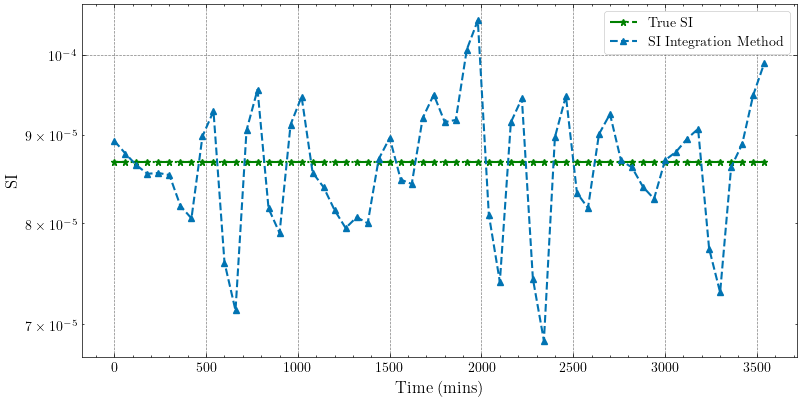

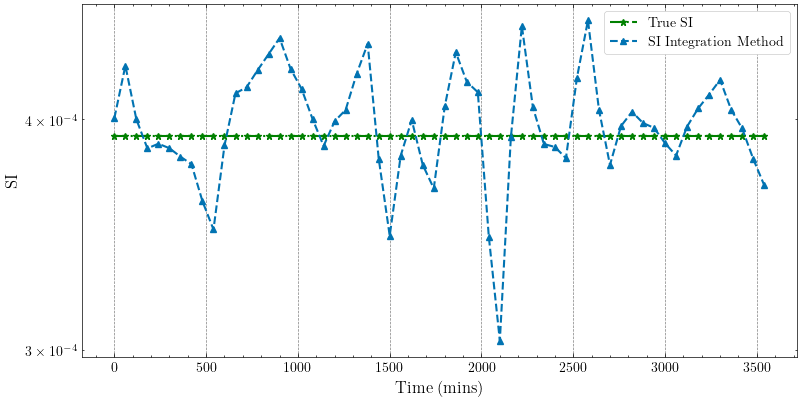

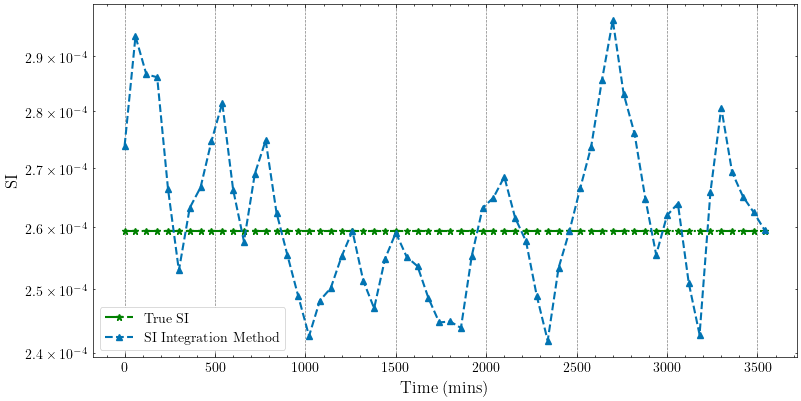

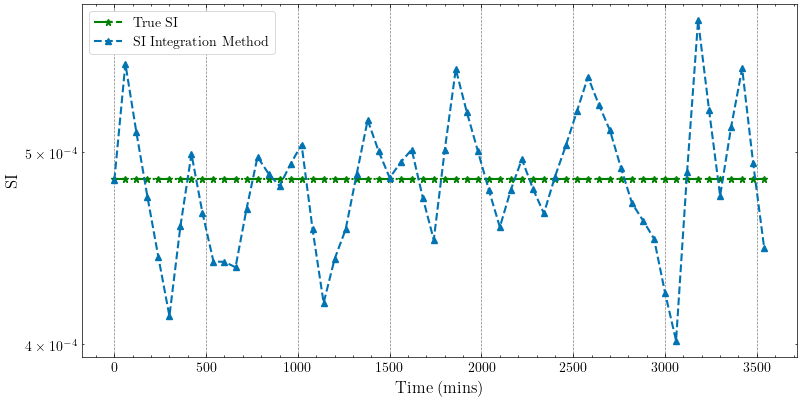

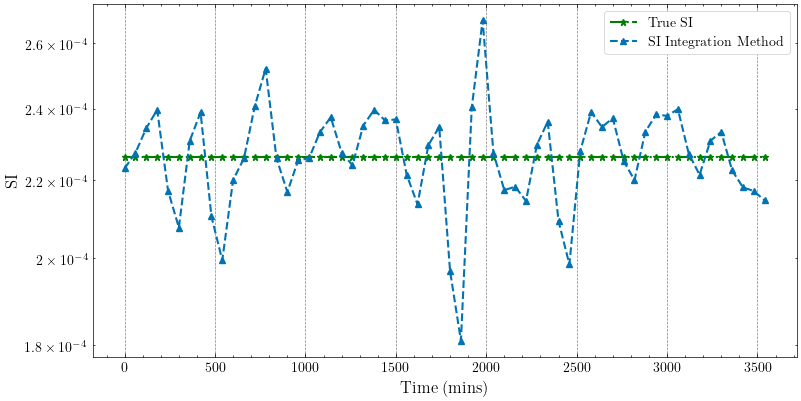

In [4]:
time = np.arange(SI_true_arr.shape[1]) * 60
palette = sns.color_palette("colorblind", 1)

for i in range(5):
    fig, ax = plt.subplots(figsize=(8, 4))
    true_SI = SI_true_arr[i, :]
    ax.semilogy(
        time, true_SI, linestyle="-.", marker="*", color="green", label="True SI"
    )
    est = SI_ests[i, :]
    ax.semilogy(
        time,
        est,
        linestyle="--",
        marker="^",
        color=palette[0],
        label="SI Integration Method",
    )
    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("SI")
    ax.legend()

In [5]:
total_mard = np.average(SI_errs, axis=(0, 1))
print("Total MARD: ", total_mard)

Total MARD:  3.5837768460762217e-09


In [6]:
try:
    SI_ests = np.load("../scripts/saved_variables/module4/SI_ests_integral_vary_04.npy")
    SI_errs = np.load(
        "../scripts/saved_variables/module4/SI_errs_integral_vary_mse_04.npy"
    )
    SI_true_arr = np.load(
        "../scripts/saved_variables/module4/SI_true_arr_integral_vary_04.npy"
    )
    print("Loaded variables")
except Exception:
    print("Run 04_Parameter_estimation_integral_vary.py")

Loaded variables


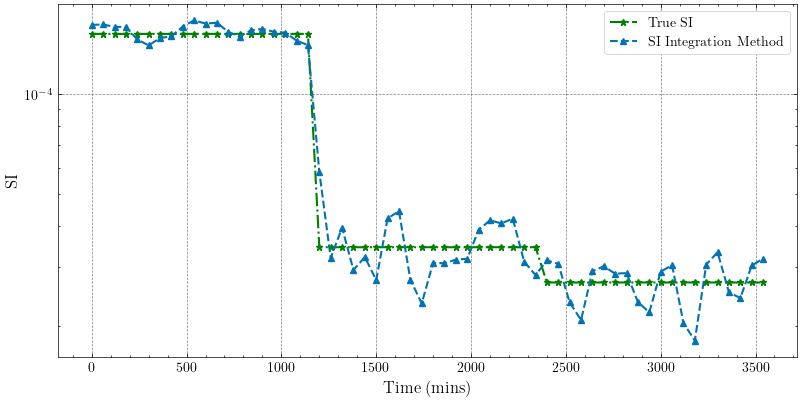

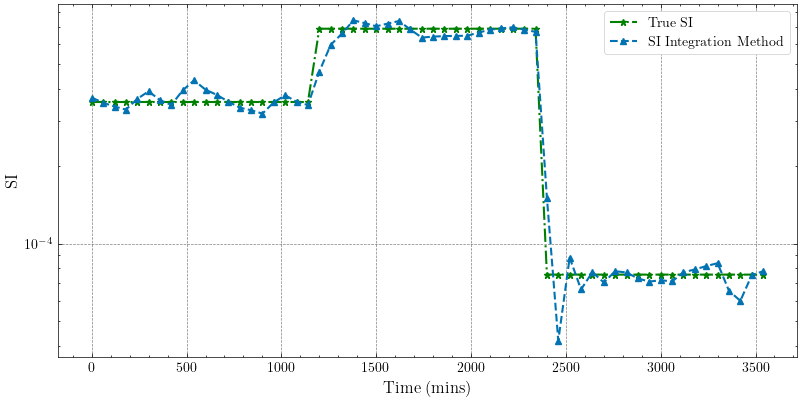

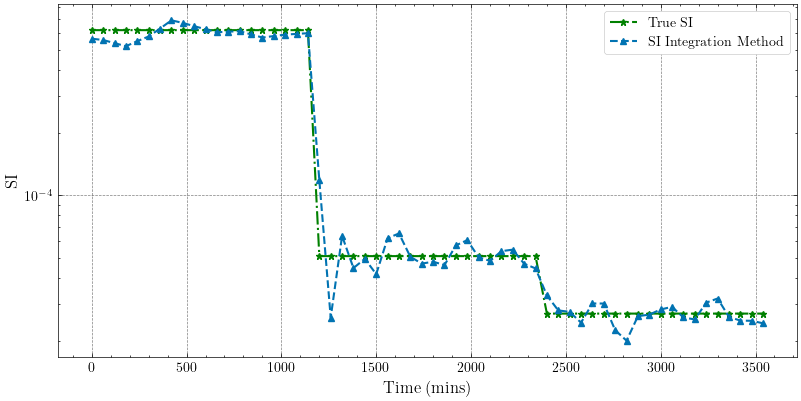

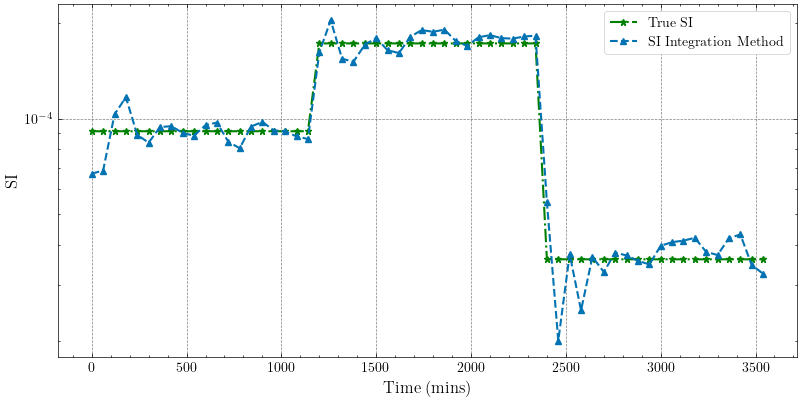

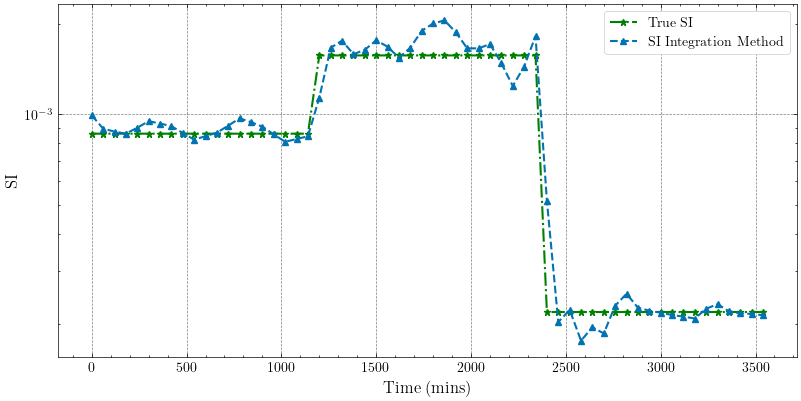

In [7]:
for i in range(5):
    fig, ax = plt.subplots(figsize=(8, 4))
    true_SI = SI_true_arr[i, :]
    ax.semilogy(
        time, true_SI, linestyle="-.", marker="*", color="green", label="True SI"
    )
    est = SI_ests[i, :]
    ax.semilogy(
        time,
        est,
        linestyle="--",
        marker="^",
        color=palette[0],
        label="SI Integration Method",
    )
    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("SI")
    ax.legend()

In [8]:
total_mard = np.median(SI_errs, axis=(0, 1))
print("Total MSE: ", total_mard)

Total MSE:  1.2175722793259711e-10


In [9]:
try:
    SI_ests = np.load(
        "../scripts/saved_variables/module4/SI_ests_augment_static_04.npy"
    )
    SI_errs = np.load(
        "../scripts/saved_variables/module4/SI_errs_augment_static_mse_04.npy"
    )
    SI_true_arr = np.load(
        "../scripts/saved_variables/module4/SI_true_arr_augment_static_04.npy"
    )
    # G_true_arr = np.load("../scripts/saved_variables/module4/G_true_arr_augment_static_04.npy")
    # states = np.load("../scripts/saved_variables/module4/states_augment_static_04.npy")
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment.py")

Loaded variables


SI process noise of 8e-4

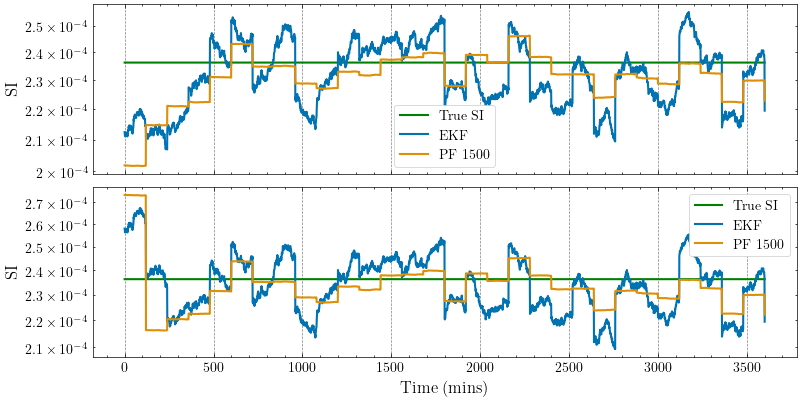

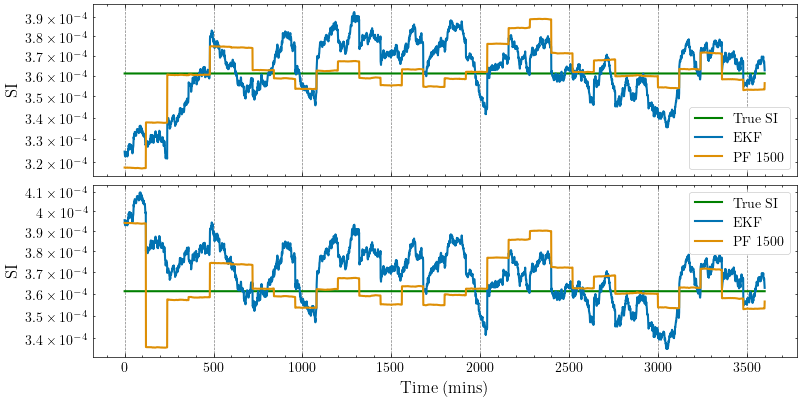

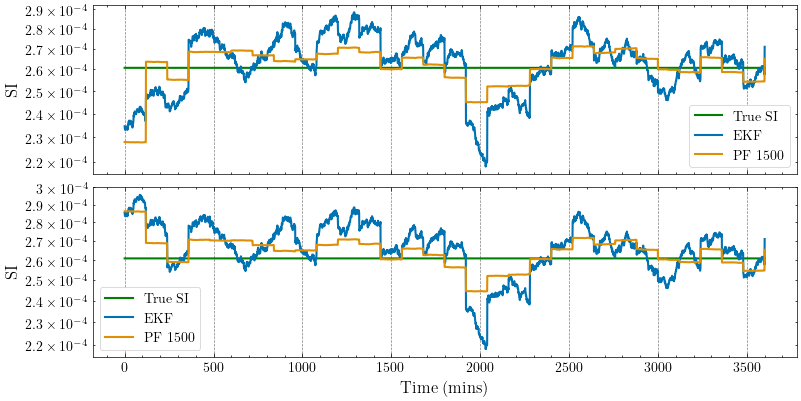

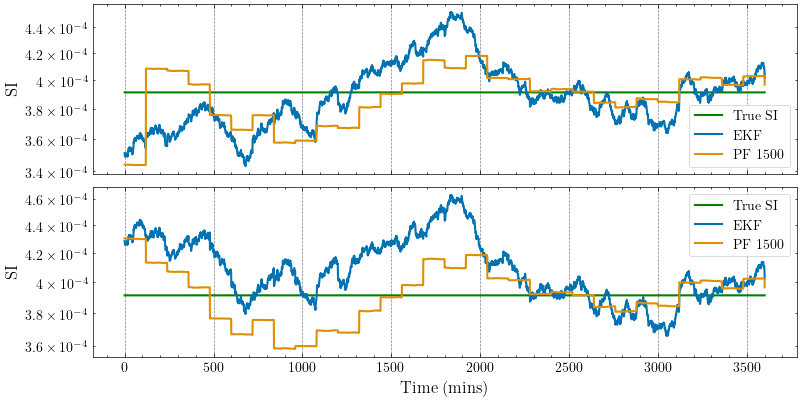

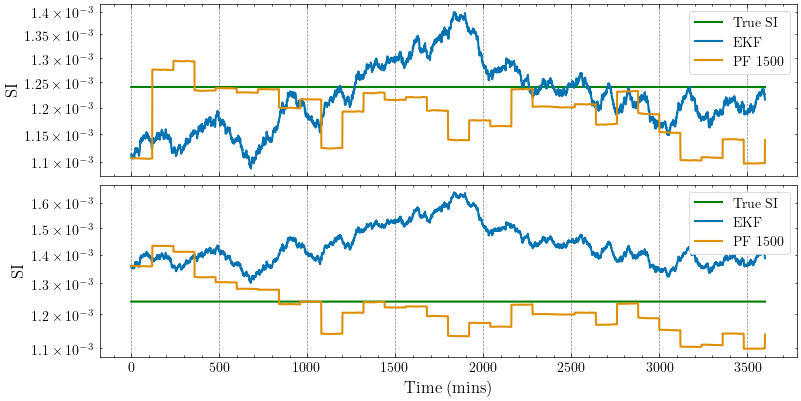

In [10]:
filters = ["EKF"]
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)
time = np.arange(SI_true_arr.shape[1])
num_filters = len(filters)
palette = sns.color_palette("colorblind", num_filters + 1)

for i in range(5):
    fig, ax = plt.subplots(num_deviations, 1, figsize=(8, 4), sharex=True)
    for j in range(num_deviations):
        true_SI = SI_true_arr[i, :]
        ax[j].semilogy(time, true_SI, color="green", label="True SI")
        for k in range(num_filters):
            patient = i
            est = SI_ests[j, k, i, :]
            ax[j].semilogy(
                time, est, linestyle="-", color=palette[k], label=f"{filters[k]}"
            )
            ax[j].set_ylabel("SI")
            ax[j].legend()

    ax[j].set_xlabel("Time (mins)")

In [11]:
mse = np.mean(SI_errs, axis=(2, 3))
std = np.std(SI_errs, axis=(2, 3))

print("Mean MSE: ", mse)
print("std: ", std)

mse = np.mean(SI_errs, axis=(0, 2, 3))
std = np.std(SI_errs, axis=(0, 2, 3))
print("Average Mean MSE: ", mse)
print("Average std: ", std)

Mean MSE:  [[9.57002492e-10 7.21452963e-10]
 [5.03486510e-09 7.02474442e-10]]
std:  [[3.26305528e-09 3.64384310e-09]
 [2.82599349e-08 3.64605923e-09]]
Average Mean MSE:  [2.99593379e-09 7.11963703e-10]
Average std:  [2.02186292e-08 3.64496369e-09]


# SI piecewise 

In [12]:
try:
    SI_ests = np.load("../scripts/saved_variables/module4/SI_ests_augment_vary_04.npy")
    # SI_ests_2500 = np.load("../scripts/saved_variables/module4/SI_ests_augment_vary_new_04.npy")
    SI_errs = np.load(
        "../scripts/saved_variables/module4/SI_errs_augment_vary_mse_04.npy"
    )
    # SI_errs_2500 = np.load("../scripts/saved_variables/module4/SI_errs_augment_vary_new_04.npy")
    SI_true_arr = np.load(
        "../scripts/saved_variables/module4/SI_true_arr_augment_vary_04.npy"
    )
    print("Loaded variables")
except Exception:
    print("Run 04_Paramater_estimation_augment_vary.py")

Loaded variables


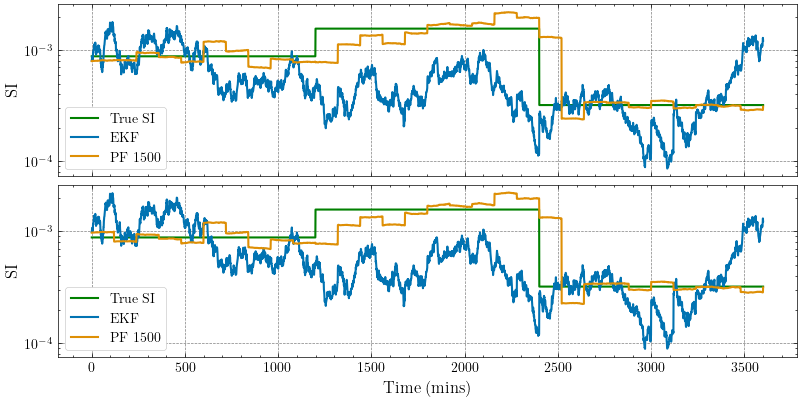

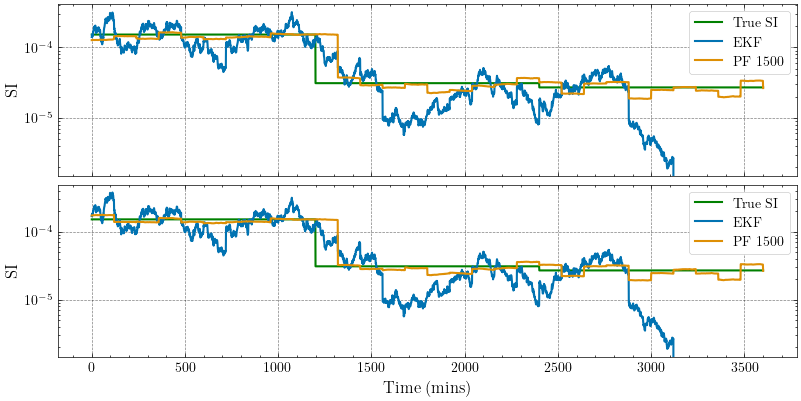

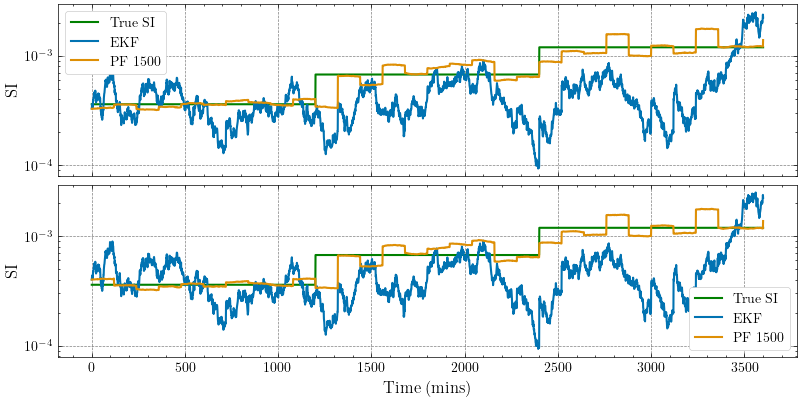

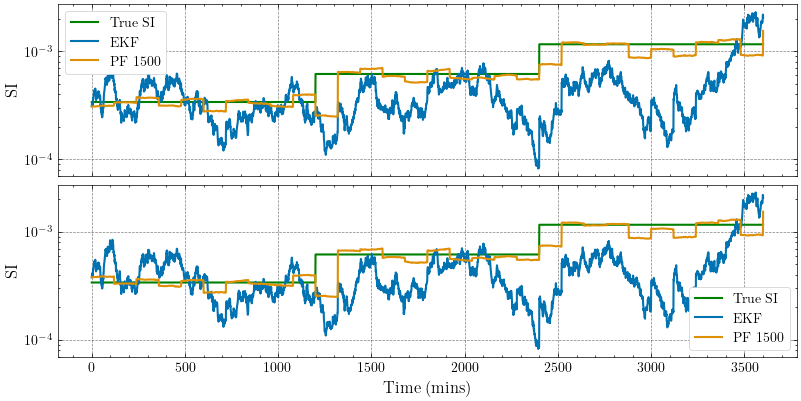

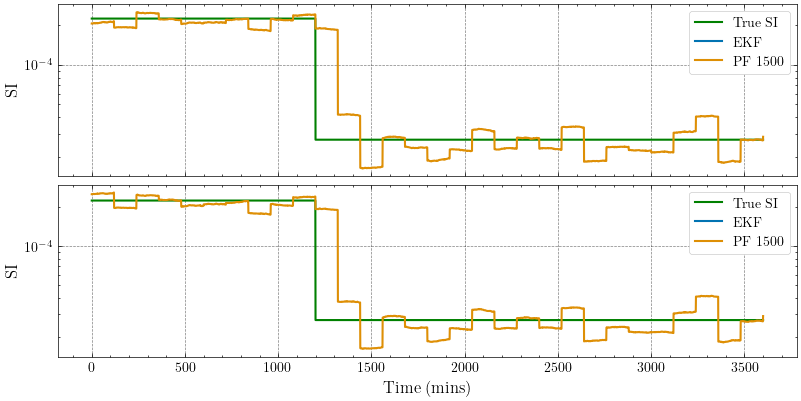

In [13]:
time = np.arange(SI_true_arr.shape[1])
num_filters = len(filters)
palette = sns.color_palette("colorblind", num_filters)

for i in range(5):
    fig, ax = plt.subplots(num_deviations, 1, figsize=(8, 4), sharex=True)
    for j in range(num_deviations):
        true_SI = SI_true_arr[i, :]
        m_true = np.isfinite(true_SI)
        ax[j].semilogy(time[m_true], true_SI[m_true], color="green", label="True SI")

        for k in range(num_filters):
            est = SI_ests[j, k, i, :]
            m = np.isfinite(est)
            ax[j].semilogy(
                time[m], est[m], linestyle="-", color=palette[k], label=f"{filters[k]}"
            )

        ax[j].set_ylabel("SI")
        ax[j].legend()
    ax[-1].set_xlabel("Time (mins)")


In [14]:
mse = np.nanmean(SI_errs, axis=(2, 3))
std = np.nanstd(SI_errs, axis=(2, 3))
print("Mean MSE: ", mse)
print("std: ", std)

mse = np.nanmean(SI_errs, axis=(0, 2, 3))
std = np.nanstd(SI_errs, axis=(0, 2, 3))
print("Average Mean MSE: ", mse)
print("Average std: ", std)

invalid_runs = (~np.isfinite(SI_ests[:, 0, :, :]).all(axis=(-1))).sum()
print("ekf failure rate: ", invalid_runs / (500 * num_deviations))

Mean MSE:  [[8.66024652e-05 2.73171066e-08]
 [9.73140381e-05 2.71737002e-08]]
std:  [[2.60536877e-03 1.82081654e-07]
 [2.64535102e-03 1.78720919e-07]]
Average Mean MSE:  [9.19582517e-05 2.72454034e-08]
Average std:  [2.62544147e-03 1.80409127e-07]
ekf failure rate:  0.304


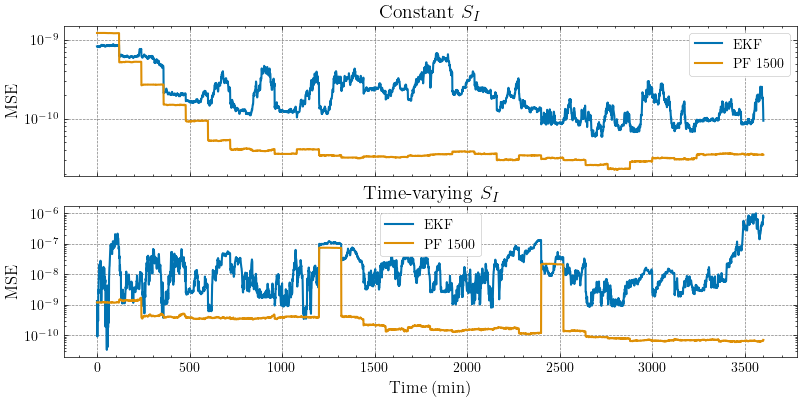

In [15]:
SI_errs_augment_static = np.load(
    "../scripts/saved_variables/module4/SI_errs_augment_static_mse_04.npy"
)
SI_errs_augment_static = np.median(SI_errs_augment_static, axis=(0,2))
SI_errs_augment_vary = np.load(
    "../scripts/saved_variables/module4/SI_errs_augment_vary_mse_04.npy"
)
SI_errs_augment_vary = np.nanmedian(SI_errs_augment_vary, axis=(0,2))

palette = sns.color_palette("colorblind", 2)
fig, ax = plt.subplots(2,1,figsize=(8, 4), sharex=True)

ax[0].plot(time,SI_errs_augment_static[0,:], color=palette[0], label = "EKF")
ax[0].plot(time,SI_errs_augment_static[1,:], color=palette[1], label = "PF 1500")
ax[0].set_yscale('log')
ax[0].set_ylabel('MSE')
ax[0].legend()
ax[0].set_title(r'Constant $S_I$')
ax[1].plot(time,SI_errs_augment_vary[0,:], color=palette[0], label = "EKF")
ax[1].plot(time,SI_errs_augment_vary[1,:], color=palette[1], label = "PF 1500")
ax[1].set_yscale('log')
ax[1].set_xlabel('Time (min)')
ax[1].set_ylabel('MSE')
ax[1].legend()
ax[1].set_title(r'Time-varying $S_I$')

fig.savefig('figures/5_10.pdf', format='pdf')